### Hyperparameter Tuning using Random Search for NAMs

In [1]:
import json
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Options for DATASET_TYPE: "synthetic" or "openml"
DATASET_TYPE = "openml"

# For synthetic datasets (when DATASET_TYPE == "synthetic"):
SYNTHETIC_TYPE = "nonlinear"  # Options: "linear" or "nonlinear"

# For OpenML datasets (when DATASET_TYPE == "openml"):
OPENML_DATASET_ID = 45402  # OpenML dataset ID (e.g., 37, 1461, etc.)
TASK_TYPE = "regression"  # Options: "classification" or "regression"

In [2]:
from hp_tuning_utils import load_hp_tuning_conf

project_root = Path.cwd().parent.parent
config_dir = project_root / 'config' / 'hp_tuning'

# Load configuration based on dataset type
if DATASET_TYPE == "openml":
    if TASK_TYPE == "classification":
        CONF_PATH = config_dir / 'openml_classification.json'
    else:
        CONF_PATH = config_dir / 'openml_regression.json'
    
    # Load config and replace <id> placeholder with actual dataset ID
    hp_search_space, fixed_hp = load_hp_tuning_conf(CONF_PATH)
    fixed_hp['dataset_name'] = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
    print(f"Loaded OpenML config: {CONF_PATH}")
    print(f"Dataset: OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}")
else:
    # Load synthetic dataset config (linear or nonlinear)
    if SYNTHETIC_TYPE == "linear":
        CONF_PATH = config_dir / 'correlated_linear.json'
    else:  # nonlinear
        CONF_PATH = config_dir / 'correlated_nonlinear.json'
    
    hp_search_space, fixed_hp = load_hp_tuning_conf(CONF_PATH)
    print(f"Loaded synthetic dataset config: {CONF_PATH}")
    print(f"Dataset: {fixed_hp.get('dataset_name', f'Correlated_{SYNTHETIC_TYPE}')}")
    print(f"Synthetic type: {SYNTHETIC_TYPE}")

print(f"Task type: {'Regression' if fixed_hp.get('regression', False) else 'Classification'}")


Instructions for updating:
non-resource variables are not supported in the long term
Loaded OpenML config: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\config\hp_tuning\openml_regression.json
Dataset: OpenML_45402_regression
Task type: Regression


In [3]:
# Random search parameters
n_trials = 50
random_seed = 42

# Get project root and set results directory
project_root = Path.cwd().parent.parent
results_dir = project_root / 'results' / 'hyperparameter_tuning' / 'nam'

# Set base_logdir based on dataset type
if DATASET_TYPE == "openml":
    base_logdir = results_dir / f'hp_tuning_openml_{OPENML_DATASET_ID}_{TASK_TYPE}'
else:
    dataset_name = fixed_hp.get('dataset_name', 'correlated_nonlinear').lower().replace(' ', '_')
    base_logdir = results_dir / f'hp_tuning_{dataset_name}'

os.makedirs(base_logdir, exist_ok=True)
print(f"Results will be saved to: {base_logdir}")

Results will be saved to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression


In [4]:
from hp_tuning_utils import sample_hyperparameters

hyperparameters = []

for trial in range(n_trials):
    trial_seed = random_seed + trial
    hp_config = sample_hyperparameters(hp_search_space, trial_seed)
    trial_num = trial + 1
    
    hyperparameters.append({
        'trial': trial_num,
        'hyperparameters': hp_config.copy()
    })


In [5]:
from hp_tuning_utils import run_trials

# Run settings
num_splits = fixed_hp['num_splits']
trials_to_run = range(1, n_trials + 1)
skip_if_exists = False
per_split_timeout_s = None

run_trials(
    fixed_hp=fixed_hp,
    hyperparameters=hyperparameters,
    base_logdir=base_logdir,
    n_trials=n_trials,
    num_splits=num_splits,
    trials_to_run=trials_to_run,
    skip_if_exists=skip_if_exists,
    per_split_timeout_s=per_split_timeout_s,
)



=== Trial 1/50 ===
Running split 1/1 for trial 1...
  Completed in 20.0s (success=True)
Saved: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\trial_1_split_results.json

=== Trial 2/50 ===
Running split 1/1 for trial 2...
  Completed in 25.3s (success=True)
Saved: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\trial_2_split_results.json

=== Trial 3/50 ===
Running split 1/1 for trial 3...
  Completed in 67.7s (success=True)
Saved: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\trial_3_split_results.json

=== Trial 4/50 ===
Running split 1/1 for trial 4...
  Completed in 17.0s (success=True)
Saved: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuni

In [6]:
import pandas as pd
from hp_tuning_utils import build_validation_scores_df

split_results_files = list(Path(base_logdir).glob('trial_*_split_results.json'))
df = build_validation_scores_df(split_results_files, base_logdir, fixed_hp)


Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\trial_10\fold_1\split_1\model_0\best_checkpoint\model.ckpt-260
Feature widths: [128, 128, 128, 128, 128, 128]
Num input features: 6
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\trial_10\fold_1\split_1\model_0\best_checkpoint\model.ckpt-260
✅ Restored NAM from checkpoint.
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\trial_11\fold_1\split_1\model_0\best_checkpoint\model.ckpt-380
Feature widths: [128, 128, 128, 128, 128, 128]
Num input features: 6
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyper

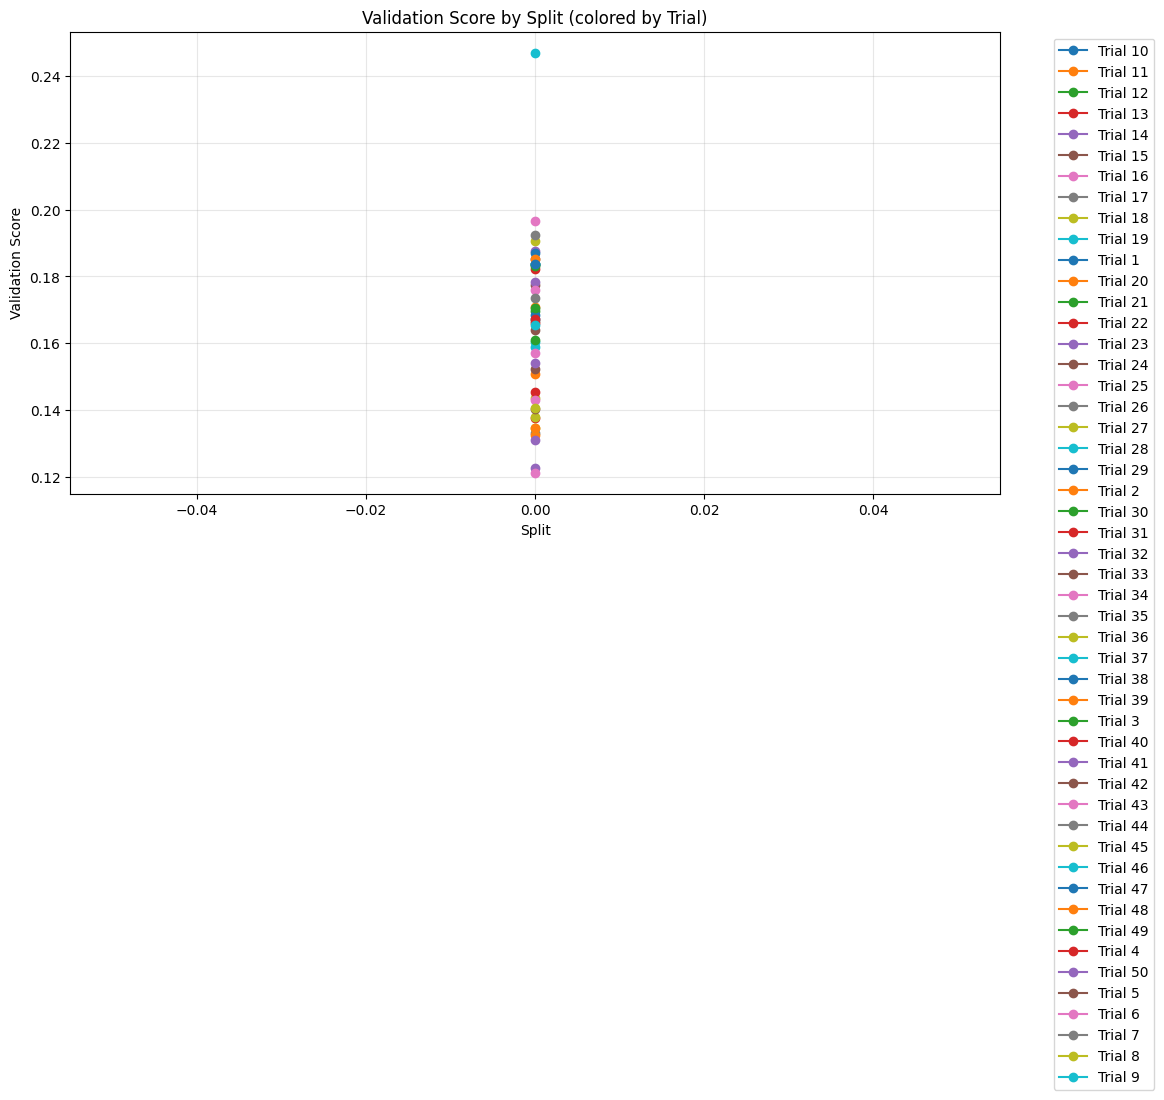

In [7]:
from hp_tuning_utils import plot_validation_score_by_split

plot_validation_score_by_split(df)


In [8]:
from hp_tuning_utils import select_and_save_best_hp


best_trial, best_data = select_and_save_best_hp(df, base_logdir)


Best trial: 16 (avg validation score: 0.1212)

Hyperparameters:
  dropout: 0
  l2_regularization: 3.740746915622769e-05
  learning_rate: 0.06092417132788725
  feature_dropout: 0.05
  output_regularization: 0.05189848778993468

Best hyperparameters saved to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\hyperparameter_tuning\nam\hp_tuning_openml_45402_regression\best_hp.json


## Train Model with Best Hyperparameters

In [9]:
# Load best hyperparameters and fixed training parameters
best_hp_path = base_logdir / 'best_hp.json'
with open(best_hp_path, 'r') as f:
    best_hp = json.load(f)

# Load fixed training parameters
config_dir = project_root / 'config' / 'training'
if DATASET_TYPE == "openml":
    if TASK_TYPE == "classification":
        training_config_path = config_dir / 'nam_training_parameters_openml_classification.json'
    else:
        training_config_path = config_dir / 'nam_training_parameters_openml_regression.json'
else:
    if SYNTHETIC_TYPE == "linear":
        training_config_path = config_dir / 'nam_training_parameters_correlated_linear.json'
    else:
        training_config_path = config_dir / 'nam_training_parameters_correlated_nonlinear.json'

with open(training_config_path, 'r') as f:
    fixed_training_params = json.load(f)

# Replace dataset name placeholder if present
if '<id>' in fixed_training_params.get('dataset_name', ''):
    fixed_training_params['dataset_name'] = fixed_training_params['dataset_name'].replace('<id>', str(OPENML_DATASET_ID))

print(f"Loaded training config from: {training_config_path}")
print(f"\nBest hyperparameters:")
for key, value in best_hp.items():
    print(f"  {key}: {value}")


Loaded training config from: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\config\training\nam_training_parameters_openml_regression.json

Best hyperparameters:
  dropout: 0
  l2_regularization: 3.740746915622769e-05
  learning_rate: 0.06092417132788725
  feature_dropout: 0.05
  output_regularization: 0.05189848778993468


In [10]:
# Set up training directory
training_results_dir = project_root / 'results' / 'training' / 'nam'

if DATASET_TYPE == "openml":
    training_logdir = training_results_dir / f'openml_{OPENML_DATASET_ID}_{TASK_TYPE}'
else:
    dataset_name = fixed_hp.get('dataset_name', 'correlated_nonlinear').lower().replace(' ', '_')
    training_logdir = training_results_dir / dataset_name

training_logdir.mkdir(parents=True, exist_ok=True)
print(f"Training results will be saved to: {training_logdir}")


Training results will be saved to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_45402_regression


In [11]:
from hp_tuning_utils import generate_training_command
import subprocess

# Combine fixed training params with best hyperparameters
all_params = {**fixed_training_params, **best_hp}
all_params['dataset_name'] = fixed_hp['dataset_name']
all_params['regression'] = fixed_hp.get('regression', False)

# Training settings
num_folds = 5  # Number of folds for cross-validation
num_splits = fixed_training_params.get('num_splits', 20)  # Number of splits per fold

print(f"Training configuration:")
print(f"  Dataset: {all_params['dataset_name']}")
print(f"  Task: {'Regression' if all_params['regression'] else 'Classification'}")
print(f"  Number of folds: {num_folds}")
print(f"  Number of splits per fold: {num_splits}")
print(f"  Training epochs: {all_params.get('training_epochs', 'N/A')}")


Training configuration:
  Dataset: OpenML_45402_regression
  Task: Regression
  Number of folds: 5
  Number of splits per fold: 20
  Training epochs: 1000


In [12]:
# Generate and run training commands for each fold and split
# Set PYTHONPATH for subprocess calls
src_path = str(project_root / 'src')
env = os.environ.copy()
if 'PYTHONPATH' in env:
    env['PYTHONPATH'] = f"{src_path}{os.pathsep}{env['PYTHONPATH']}"
else:
    env['PYTHONPATH'] = src_path

# Force CPU-only mode to avoid CUDA errors
env['CUDA_VISIBLE_DEVICES'] = ''

for fold in range(1, num_folds + 1):
    print(f"\n{'='*70}")
    print(f"Training Fold {fold}/{num_folds}")
    print(f"{'='*70}")
    
    for split in range(1, num_splits + 1):
        # Set fold and split specific parameters
        all_params['fold_num'] = fold
        all_params['data_split'] = split
        
        # So we just pass the base training_logdir
        all_params['logdir'] = str(training_logdir)
        
        # Generate training command
        cmd_parts = ['python', '-m', 'neural_additive_models.nam_train']
        for key, value in all_params.items():
            if value is None:
                cmd_parts.append(f'--{key}=None')
            elif isinstance(value, bool):
                cmd_parts.append(f'--{key}={"true" if value else "false"}')
            else:
                cmd_parts.append(f'--{key}={value}')
        
        cmd = ' '.join(cmd_parts)
        
        print(f"\nFold {fold}, Split {split}/{num_splits}...")
        print(f"Command: {cmd[:100]}...")  # Print first 100 chars
        
        # Run training
        result = subprocess.run(
            cmd,
            shell=True,
            capture_output=True,
            text=True,
            env=env,
        )
        
        if result.returncode == 0:
            print(f"  ✅ Completed successfully")
        else:
            print(f"  ❌ Failed (return code: {result.returncode})")
            if result.stderr:
                # Print last 500 chars of error (most relevant part)
                error_msg = result.stderr.strip()
                if len(error_msg) > 500:
                    print(f"  Error (last 500 chars): ...{error_msg[-500:]}")
                else:
                    print(f"  Error: {error_msg}")
            if result.stdout:
                # Sometimes errors are in stdout
                stdout_msg = result.stdout.strip()
                if 'Error' in stdout_msg or 'Traceback' in stdout_msg:
                    if len(stdout_msg) > 500:
                        print(f"  Output (last 500 chars): ...{stdout_msg[-500:]}")
                    else:
                        print(f"  Output: {stdout_msg}")

print(f"\n{'='*70}")
print("Training completed!")
print(f"Results saved to: {training_logdir}")
print(f"{'='*70}")



Training Fold 1/5

Fold 1, Split 1/20...
Command: python -m neural_additive_models.nam_train --dataset_name=OpenML_45402_regression --regression=true ...
  ✅ Completed successfully

Fold 1, Split 2/20...
Command: python -m neural_additive_models.nam_train --dataset_name=OpenML_45402_regression --regression=true ...
  ✅ Completed successfully

Fold 1, Split 3/20...
Command: python -m neural_additive_models.nam_train --dataset_name=OpenML_45402_regression --regression=true ...
  ✅ Completed successfully

Fold 1, Split 4/20...
Command: python -m neural_additive_models.nam_train --dataset_name=OpenML_45402_regression --regression=true ...
  ✅ Completed successfully

Fold 1, Split 5/20...
Command: python -m neural_additive_models.nam_train --dataset_name=OpenML_45402_regression --regression=true ...
  ✅ Completed successfully

Fold 1, Split 6/20...
Command: python -m neural_additive_models.nam_train --dataset_name=OpenML_45402_regression --regression=true ...
  ✅ Completed successfully

Fo